In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score,confusion_matrix,classification_report
import matplotlib as plt
import seaborn as sns
from glob import glob
import torch.nn as nn
import cv2
import torch
import torchvision
from torchvision.transforms import transforms
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

In [8]:
import tensorflow_datasets as tfds

dataset = tfds.load("cifar10", split="train", as_supervised=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.BXLRAO_3.0.2/cifar10-train.tfrecord*...:   0%|         …

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cifar10/incomplete.BXLRAO_3.0.2/cifar10-test.tfrecord*...:   0%|          …

Dataset cifar10 downloaded and prepared to /root/tensorflow_datasets/cifar10/3.0.2. Subsequent calls will reuse this data.


In [9]:
for image, label in dataset.take(1):
    print(image.shape)  # (32, 32, 3)
    print(label)        # class index

(32, 32, 3)
tf.Tensor(7, shape=(), dtype=int64)


In [10]:
import tensorflow as tf

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

dataset = dataset.map(preprocess)
dataset = dataset.shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)


In [11]:
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")



Torch version: 2.10.0+cu128
CUDA available: True
CUDA device: Tesla T4


In [12]:
if  torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.xpu.is_available():
    device = torch.device("xpu")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [13]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [14]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [44]:
import tensorflow as tf
from tensorflow.keras import layers, models


model = tf.keras.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [45]:
tf_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)

# Using the tf_resnet_model ensures we use the Keras compile method
model.compile(optimizer=tf_optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [46]:
model.fit(dataset, epochs=50)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - accuracy: 0.3023 - loss: 2.1879
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.4270 - loss: 1.6350
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4946 - loss: 1.4312
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.5471 - loss: 1.2760
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5910 - loss: 1.1619
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6213 - loss: 1.0842
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6434 - loss: 1.0249
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6646 - loss: 0.9747
Epoch 9/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6766 - loss: 0.9305
Epoch 10/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6923 - loss: 0.8915
Epoch 11/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6985 - loss: 0.8705
Epoch 12/50
1563/1563 

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8072 - loss: 0.5656

Test Accuracy: 0.8072

Classification Report:
              precision    recall  f1-score   support

       plane       0.85      0.80      0.82      1000
         car       0.91      0.90      0.90      1000
        bird       0.76      0.68      0.72      1000
         cat       0.73      0.56      0.63      1000
        deer       0.76      0.81      0.79      1000
         dog       0.72      0.74      0.73      1000
        frog       0.73      0.93      0.82      1000
       horse       0.87      0.85      0.86      1000
        ship       0.89      0.88      0.89      1000
       truck       0.86      0.92      0.89      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.80     10000
weighted avg       0.81      0.81      0.80     10000



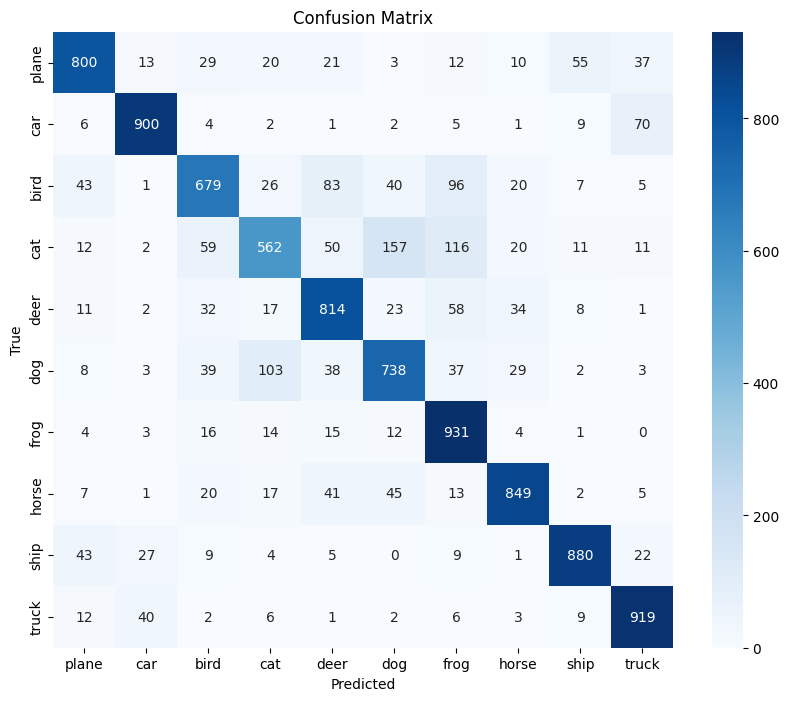

In [47]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_ds = tfds.load('cifar10', split='test', as_supervised=True)
test_ds = test_ds.map(preprocess).batch(32)
loss, accuracy = model.evaluate(test_ds)
print(f'\nTest Accuracy: {accuracy:.4f}')

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Classification Report
print('\nClassification Report:')
print(classification_report(y_true, y_pred, target_names=classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [49]:
# 6. Save the model
model.save("model.keras")
print(f'Model saved successfully to {model_save_path}')

Model saved successfully to cifar10_simple_cnn.h5



📂 Upload an image:


Saving download (2).jpg to download (2) (1).jpg


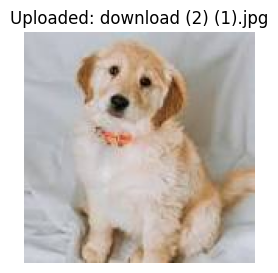


 Prediction Results for 'download (2) (1).jpg':
    Predicted Class : DOG
   Confidence      : 95.62%

📈 All Class Probabilities:
   airplane      0.02%  
   automobile    0.00%  
   bird          2.14%  
   cat           1.93%  
   deer          0.08%  
   dog          95.62%  ████████████████████████████ ◀ TOP
   frog          0.15%  
   horse         0.01%  
   ship          0.05%  
   truck         0.00%  


In [83]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import io

CLASS_NAMES = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

# --- Load your saved Keras model ---
keras_model = tf.keras.models.load_model("model.keras")

# --- Upload Image ---
print("\n📂 Upload an image:")
uploaded = files.upload()

for filename, content in uploaded.items():
    # Open & display
    image = Image.open(io.BytesIO(content)).convert("RGB")
    plt.figure(figsize=(3, 3))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Uploaded: {filename}")
    plt.show()

    # Preprocess (same as training)
    img_resized = image.resize((32, 32))
    img_array = np.array(img_resized) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # shape: (1, 32, 32, 3)

    # Predict
    preds = keras_model.predict(img_array, verbose=0)
    class_idx = int(np.argmax(preds[0]))
    confidence = float(np.max(preds[0])) * 100

    # Results
    print(f"\n Prediction Results for '{filename}':")
    print(f"    Predicted Class : {CLASS_NAMES[class_idx].upper()}")
    print(f"   Confidence      : {confidence:.2f}%\n")

    print("📈 All Class Probabilities:")
    for i, (cls, prob) in enumerate(zip(CLASS_NAMES, preds[0])):
        bar = "█" * int(prob * 30)
        marker = " ◀ TOP" if i == class_idx else ""
        print(f"   {cls:<12} {prob*100:5.2f}%  {bar}{marker}")